In [1]:
!pip install pytorch-lightning pytorch-forecasting

In [2]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

In [3]:
df = pd.read_csv("combined_scaled_battery_data.csv")
print(df.shape)
print(df.columns)
df.head()

(17658, 10)
Index(['Cycle_Index', 'Discharge Time (s)', 'Decrement 3.6-3.4V (s)',
       'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)',
       'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)',
       'RUL', 'Is_NASA'],
      dtype='object')


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL,Is_NASA
0,1.0,0.909368,2.248505,-2.808054,-3.115605,2.005705,1.867079,2.297202,1112,0
1,2.0,5.241828,2.317965,4.102902,-3.039831,2.045062,1.871526,2.039997,1111,0
2,3.0,5.228434,2.121319,4.138897,-3.006154,2.045063,1.871526,1.965868,1110,0
3,4.0,5.220999,2.013378,4.150895,-2.997735,2.039458,1.871526,1.875424,1109,0
4,6.0,57.099956,96.943238,4.630822,-1.541204,2.022568,31.339883,44.865103,1107,0


In [4]:
df = df.rename(columns={
    "Cycle_Index": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target"
})

In [6]:
df = df.reset_index(drop=True)
df["battery_id"] = (df["time_idx"] == 1).cumsum() - 1

In [10]:
print(df[["battery_id", "time_idx", "target", "Is_NASA"]].head(30))

    battery_id  time_idx  target  Is_NASA
0            0       1.0    1112        0
1            0       2.0    1111        0
2            0       3.0    1110        0
3            0       4.0    1109        0
4            0       6.0    1107        0
5            0       7.0    1106        0
6            0       8.0    1105        0
7            0       9.0    1104        0
8            0      10.0    1103        0
9            0      12.0    1101        0
10           0      13.0    1100        0
11           0      14.0    1099        0
12           0      15.0    1098        0
13           0      17.0    1096        0
14           0      18.0    1095        0
15           0      19.0    1094        0
16           0      20.0    1093        0
17           0      21.0    1092        0
18           0      22.0    1091        0
19           0      23.0    1090        0
20           0      24.0    1089        0
21           0      25.0    1088        0
22           0      26.0    1087  

In [11]:
print("num batteries:", df["battery_id"].nunique())
print("duplicate pairs:", df.duplicated(subset=["battery_id", "time_idx"]).sum())

print("\nmin time_idx per battery:")
print(df.groupby("battery_id")["time_idx"].min().head())

print("\nmax time_idx per battery:")
print(df.groupby("battery_id")["time_idx"].max().head())

num batteries: 48
duplicate pairs: 0

min time_idx per battery:
battery_id
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: time_idx, dtype: float64

max time_idx per battery:
battery_id
0    1112.0
1    1107.0
2    1107.0
3    1107.0
4    1133.0
Name: time_idx, dtype: float64


In [12]:
df = df.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)

In [13]:
df["battery_id"] = df["battery_id"].astype(str)
df["time_idx"] = df["time_idx"].astype(int)
df["Is_NASA"] = df["Is_NASA"].astype(float)

In [14]:
from sklearn.model_selection import train_test_split

battery_ids = df["battery_id"].unique()

train_ids, test_ids = train_test_split(battery_ids, test_size=0.2, random_state=42)
train_ids, val_ids = train_test_split(train_ids, test_size=0.2, random_state=42)

train_df = df[df["battery_id"].isin(train_ids)].copy()
val_df = df[df["battery_id"].isin(val_ids)].copy()
test_df = df[df["battery_id"].isin(test_ids)].copy()

print(train_df.shape, val_df.shape, test_df.shape)
print("Train batteries:", train_df["battery_id"].nunique())
print("Val batteries:", val_df["battery_id"].nunique())
print("Test batteries:", test_df["battery_id"].nunique())

(13216, 11) (1701, 11) (2741, 11)
Train batteries: 30
Val batteries: 8
Test batteries: 10


In [16]:
print(train_df.dtypes)
print()

print("duplicate (battery_id, time_idx):",
      train_df.duplicated(subset=["battery_id", "time_idx"]).sum())

print("num batteries:", train_df["battery_id"].nunique())
print()

group_lengths = train_df.groupby("battery_id").size()
print("min group length:", group_lengths.min())
print("max group length:", group_lengths.max())
print(group_lengths.head())

time_idx                   int64
discharge_time           float64
decrement_36_34          float64
max_voltage_discharge    float64
min_voltage_charge       float64
time_at_415              float64
time_constant_current    float64
charging_time            float64
target                     int64
Is_NASA                  float64
battery_id                object
dtype: object

duplicate (battery_id, time_idx): 0
num batteries: 30

min group length: 24
max group length: 1067
battery_id
0     1063
1     1065
10    1064
11    1065
13    1039
dtype: int64


In [17]:
from pytorch_forecasting import TimeSeriesDataSet

max_encoder_length = 20
max_prediction_length = 1

training = TimeSeriesDataSet(
    train_df,
    time_idx="time_idx",
    target="target",
    group_ids=["battery_id"],

    min_encoder_length=1,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,

    static_categoricals=[],
    static_reals=["Is_NASA"],

    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[
        "discharge_time",
        "decrement_36_34",
        "max_voltage_discharge",
        "min_voltage_charge",
        "time_at_415",
        "time_constant_current",
        "charging_time",
    ],

    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
    target_normalizer=None,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training, val_df, predict=False, stop_randomization=True
)

test = TimeSeriesDataSet.from_dataset(
    training, test_df, predict=False, stop_randomization=True
)

In [18]:
train_dataloader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)
test_dataloader = test.to_dataloader(train=False, batch_size=64, num_workers=0)

In [19]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=16,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=1,
    loss=RMSE(),
    reduce_on_plateau_patience=3
)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=5,
    mode="min"
)

trainer = Trainer(
    max_epochs=20,
    accelerator="auto",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback]
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [20]:
import torch
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

predictions = tft.predict(test_dataloader)
actuals = torch.cat([y[0] for x, y in iter(test_dataloader)])

preds = predictions.squeeze().cpu().numpy()
acts = actuals.squeeze().cpu().numpy()

mae = mean_absolute_error(acts, preds)
rmse = np.sqrt(mean_squared_error(acts, preds))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


MAE:  22.6152
RMSE: 36.0381


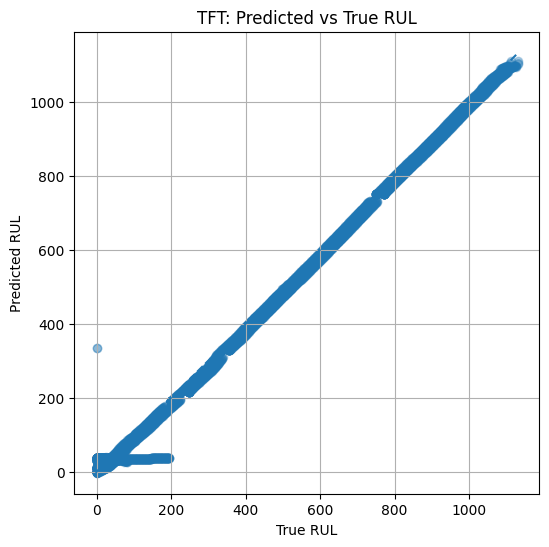

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(acts, preds, alpha=0.3)

mn = min(acts.min(), preds.min())
mx = max(acts.max(), preds.max())
plt.plot([mn, mx], [mn, mx], "--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("TFT: Predicted vs True RUL")
plt.grid(True)
plt.show()

In [26]:
import os
import pandas as pd

metrics_path = "/Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/lightning_logs/version_0/metrics.csv"
history_df = pd.read_csv(metrics_path)

print(history_df.head())
print(history_df.columns.tolist())

   epoch  step  train_loss_epoch  train_loss_step    val_MAE     val_MAPE  \
0      0    49               NaN       499.323151        NaN          NaN   
1      0    99               NaN       315.317810        NaN          NaN   
2      0   149               NaN       186.162094        NaN          NaN   
3      0   199               NaN        74.710205        NaN          NaN   
4      0   220               NaN              NaN  44.895947  627909568.0   

    val_RMSE  val_SMAPE   val_loss  
0        NaN        NaN        NaN  
1        NaN        NaN        NaN  
2        NaN        NaN        NaN  
3        NaN        NaN        NaN  
4  53.843754   0.479593  53.843754  
['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val_MAE', 'val_MAPE', 'val_RMSE', 'val_SMAPE', 'val_loss']


train column: train_loss_epoch
val column: val_loss


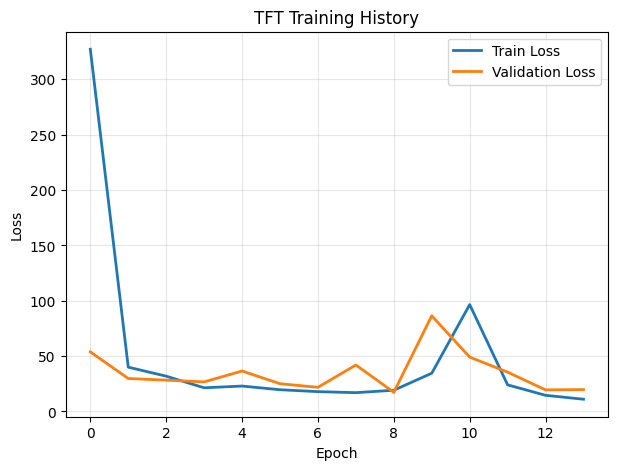

In [27]:
import matplotlib.pyplot as plt

# find likely column names
train_col = None
val_col = None

for c in history_df.columns:
    if c in ["train_loss", "train_loss_epoch", "loss"]:
        train_col = c
    if c in ["val_loss", "valid_loss"]:
        val_col = c

print("train column:", train_col)
print("val column:", val_col)

train_loss = history_df[["epoch", train_col]].dropna() if train_col is not None else None
val_loss = history_df[["epoch", val_col]].dropna() if val_col is not None else None

plt.figure(figsize=(7, 5))

if train_loss is not None:
    plt.plot(train_loss["epoch"], train_loss[train_col], label="Train Loss", linewidth=2)

if val_loss is not None:
    plt.plot(val_loss["epoch"], val_loss[val_col], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TFT Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()